# 1. Data Explorer

In [2]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os

data_path = Path("./data")
train_dir = Path(os.path.join("./data", "train"))
test_dir = Path(os.path.join("./data", "test"))
val_dir = Path(os.path.join("./data", "validation"))

device = "cuda" if torch.cuda.is_available() else "cpu"
device, test_dir, train_dir

('cpu', WindowsPath('data/test'), WindowsPath('data/train'))

In [3]:
# # Spearate train data to train and validation
# import pathlib
# from torchvision.io import read_image
# from torchvision.utils import save_image

# flower_classes = os.listdir(train_dir)
# print(f"flower classes: {flower_classes}")

# for flower_class in flower_classes:
#     img_paths = list(pathlib.Path(train_dir).glob(f"{flower_class}/*.jpg"))
#     torch.manual_seed(42)
#     for i in range(int(len(img_paths)*0.2)):
#         random_img_path = img_paths[torch.randint(len(img_paths), size=(1,)).item()]
#         img= read_image(str(random_img_path))/255.0
#         path_validation = os.path.join(".","data","validation", random_img_path.parent.stem, random_img_path.name)
#         path_train = os.path.join(".","data","train", random_img_path.parent.stem, random_img_path.name)
#         save_image(img, path_validation, normalize=True)
#         os.remove(str(path_train))
#         img_paths = list(pathlib.Path(train_dir).glob("*/*.jpg"))


In [4]:
# walk through each of the subdirectories and count the file present
def walk_through_dir(dir_path = "."):
  """
  Walks through dir_path returning its contents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
  """ 
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [5]:
walk_through_dir("./data")

There are 4 directories and 0 images in './data'.
There are 0 directories and 1 images in './data\logs'.
There are 0 directories and 924 images in './data\test'.
There are 5 directories and 0 images in './data\train'.
There are 0 directories and 401 images in './data\train\daisy'.
There are 0 directories and 521 images in './data\train\dandelion'.
There are 0 directories and 404 images in './data\train\rose'.
There are 0 directories and 406 images in './data\train\sunflower'.
There are 0 directories and 503 images in './data\train\tulip'.
There are 5 directories and 0 images in './data\validation'.
There are 0 directories and 100 images in './data\validation\daisy'.
There are 0 directories and 123 images in './data\validation\dandelion'.
There are 0 directories and 93 images in './data\validation\rose'.
There are 0 directories and 89 images in './data\validation\sunflower'.
There are 0 directories and 100 images in './data\validation\tulip'.


## 1.1 Visualize some images


Let's write some code to:
1. Get all of the image paths using [`pathlib.Path.glob()`](https://docs.python.org/3/library/pathlib.html#pathlib.Path.glob) to find all of the files ending in `.jpg`. 
2. Pick a random image path using Python's [`random.choice()`](https://docs.python.org/3/library/random.html#random.choice).
3. Get the image class name using [`pathlib.Path.parent.stem`](https://docs.python.org/3/library/pathlib.html#pathlib.PurePath.parent).
4. And since we're working with images, we'll open the random image path using [`PIL.Image.open()`](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.open) (PIL stands for Python Image Library).
5. We'll then show the image and print some metadata.

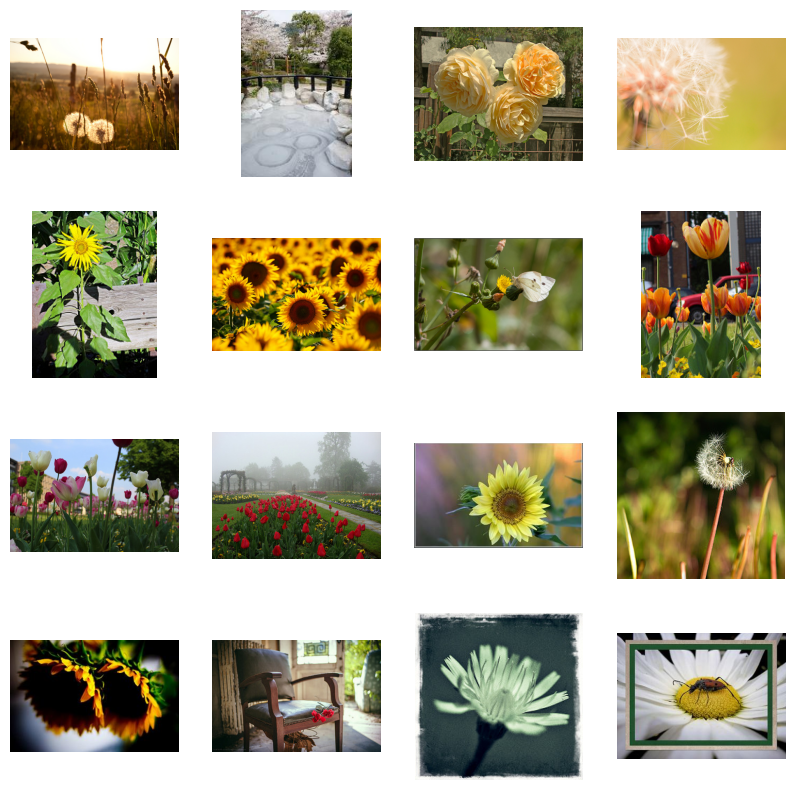

In [6]:
# set seed
# torch.manual_seed(2)

# 1. Get all image paths
image_path_list = list(data_path.glob("*/*/*.jpg"))

fig = plt.figure(figsize=(10, 10))
rows, cols = 4, 4
for i in range(1, rows*cols + 1):
    random_idx = torch.randint(0, len(image_path_list), size=(1,)).item()
    img_path = image_path_list[random_idx]
    img = Image.open(img_path)

    fig.add_subplot(rows, cols, i)
    plt.imshow(img)
    plt.axis("off")
plt.show()


# 2. Transforming data with **torchvision.transforms**

In [7]:
# Transform composed of a series of transforms to perform on an image
data_transform = transforms.Compose([
    # resize the image to 64x64
    transforms.Resize((64, 64)),
    # flip the image randomly on the horizontal with a probability of 0.5
    transforms.RandomHorizontalFlip(p=0.5),
    # random crop the image to 64x64
    transforms.RandomCrop(size=(64, 64)),
    # apply the TrivialAugmentWide data augmentation technique to the image
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    # convert the image to a tensor, this also scales the image's pixel values from 0-255 to 0-1
    transforms.ToTensor() 
])

In [8]:
# Check image afer transform
def plot_transformed_images(image_paths, transform,n=3, seed:int= None):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths. 
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    if seed:
        torch.manual_seed(seed)

    for i in range(n):
        random_idx = torch.randint(0, len(image_paths), size=(1,)).item()
        img_path = image_paths[random_idx]
        img = Image.open(img_path)
        transformed_img = transform(img)
        fig, ax = plt.subplots(1, 2)
        ax[0].imshow(img)
        ax[0].set_title("Original Image")
        ax[0].axis("off")
             
        ax[1].imshow(transformed_img.permute(1, 2, 0))
        ax[1].set_title("Transformed Image")  
        ax[1].axis("off")

        fig.suptitle(f"Class: {img_path.parent.stem}")

  



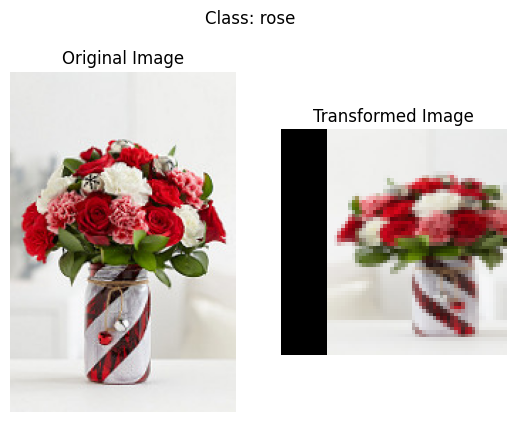

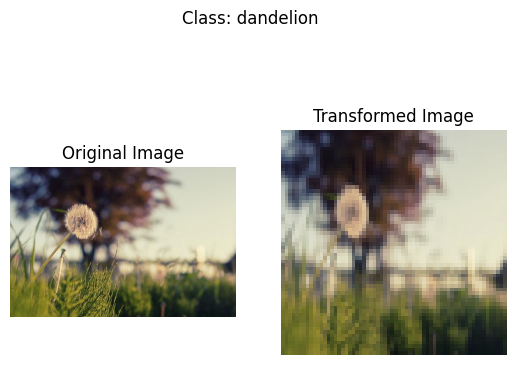

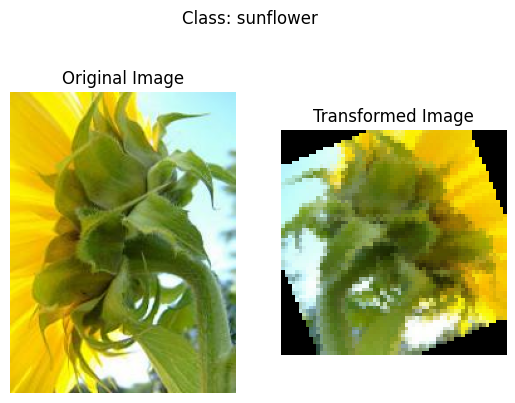

In [9]:
plot_transformed_images(image_path_list, data_transform, n=3)

# 3. Create custom dataset for loading image data

In [10]:
from torch.utils.data import Dataset
from typing import Tuple, Dict, List

## 3.1 Create a function to find the class names in a target directory

In [11]:

def find_class(dir_path: Path):
    """Finds the class folder names in a target directory.
    
    Assumes target directory is in standard image classification format.

    Args:
        dir_path (Path): Target directory path.

    Returns:
        Tuple[List[str], Dict[str, int]]: (list_of_class_names, dict(class_name: idx...))
    
    Example:
        find_classes("food_images/train")
        >>> (["class_1", "class_2"], {"class_1": 0, ...})
    """
    # 1. get the class name by scanning the target directory
    classes = sorted(item.name for item in os.scandir(dir_path) if item.is_dir())

    # 2. Raise an error if class names not found
    if not classes:
        print(f"Couldn't find any class folder in {dir_path}.")
    
    # 3. Create a class to index mapping
    class_to_idx = {idx: cls_name for idx, cls_name in enumerate(classes)}
    return classes, class_to_idx

In [12]:
class_names, class_names_idx = find_class(os.path.join(data_path, "train"))
class_names, class_names_idx

(['daisy', 'dandelion', 'rose', 'sunflower', 'tulip'],
 {0: 'daisy', 1: 'dandelion', 2: 'rose', 3: 'sunflower', 4: 'tulip'})

## 3.2 Create a custom dataset class

In [13]:

import pathlib


class CustomImageDataset(Dataset):
    # Initialize with a target directory and transforms
    def __init__(self, dir_path: Path, transform=None) -> None:
        # get all image paths
        self.paths = list(pathlib.Path(dir_path).glob("*/*.jpg")) # update this if your image format is not .jpg
        # setup transforms
        self.transform = transform
        self.classes, self.class_to_idx = find_class(dir_path)
    
    # Make function to load images
    def load_image(self, index: int) -> Image.Image:
        # Open the image at index
        img_path = self.paths[index]
        return Image.open(img_path)
    
    #Overwrite the _len__ method to return the length of the dataset
    def __len__(self) -> int:
        "Returns the total number of samples in the dataset."
        return len(self.paths)
    
    # Overwrite the __getitem__ method to return a sample from the dataset at the given index
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
        "Returns one sample of data, data and label (X,y)."
        img = self.load_image(index)
        class_name = self.paths[index].parent.stem
        class_idx = next((k for k,v in self.class_to_idx.items() if v == class_name), None)

        # Transform if necessary
        if self.transform:
            return self.transform(img), class_idx # return the image and the label
        else:
            return img, class_idx # return the image and the label

## 3.3 Function to display random images from a dataset (check the dataset is working)

In [14]:

def display_random_images(dataset: torch.utils.data.dataset.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
    
    # 2. Adjust display if n too high
    if n > 10:
        n = 10
        display_shape = False
        print(f"For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display.")
    
    # 3. Set random seed
    if seed:
        torch.manual_seed(seed)

    # 4. Get random sample indexes
    random_samples_idx = torch.randint(0, len(dataset), (n,))

    # 5. Setup plot
    plt.figure(figsize=(16, 8))

    # 6. Loop through samples and display random samples 
    for i, targ_sample in enumerate(random_samples_idx):
        targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

        # 7. Adjust image tensor shape for plotting: [color_channels, height, width] -> [color_channels, height, width]
        targ_image_adjust = targ_image.permute(1, 2, 0)

        # Plot adjusted samples
        plt.subplot(1, n, i+1)
        plt.imshow(targ_image_adjust)
        plt.axis("off")
        if classes:
            title = f"class: {classes[targ_label]}"
            if display_shape:
                title = title + f"\nshape: {targ_image_adjust.shape}"
        plt.title(title)

In [15]:
# # Augment train data
# train_transforms = transforms.Compose([
#     # resize the image to 64x64
#     transforms.Resize((64, 64)),
#     # flip the image randomly on the horizontal with a probability of 0.5
#     transforms.RandomHorizontalFlip(p=0.5),
#     # random crop the image to 64x64
#     transforms.RandomCrop(size=(64, 64)),
#     # apply the TrivialAugmentWide data augmentation technique to the image
#     transforms.TrivialAugmentWide(num_magnitude_bins=31),
#     # convert the image to a tensor, this also scales the image's pixel values from 0-255 to 0-1
#     transforms.ToTensor() 
# ])

# # Don't augment test data, only reshape
# val_transforms = transforms.Compose([
#     transforms.Resize((64, 64)),
#     transforms.ToTensor()
# ])

# 4.Create train function

In [16]:
# train loop

def train_step(model:torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches

    for batch, (X,y) in enumerate(dataloader):
        # send data to target device
        X, y = X.to(device), y.to(device)

        # 1. forward pass
        y_pred =  model(X)

        # 2. Calculate and accummulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)
    
    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc
    


        


In [17]:
# test step

def test_step(model: torch.nn.Module, 
              dataloader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval() 
    
    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0
    
    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)
    
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
            
    # Adjust metrics to get average loss and accuracy per batch 
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [21]:
from tqdm.auto import tqdm
from torch import nn

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module, 
          train_dataloader: torch.utils.data.DataLoader, 
          test_dataloader: torch.utils.data.DataLoader, 
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    
    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }
    
    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)
        
        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

# 5. Model 0: **TinyVGG** without data augmentation

## 5.1 Creating transfoms and loading data for Model 0

In [22]:
# ceate transforms for train and validation data
simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# # Don't augment test data, only reshape
val_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [ ]:
# 1. Loading data for training and testing
train_data_model_0 = CustomImageDataset(train_dir, transform=simple_transform)
val_data_model_0 = CustomImageDataset(val_dir, transform=val_transforms)

# 2. Turn data into DataLoader
BATCH_SIZE = 32
# NUM_WORKERS = os.cpu_count() 
NUM_WORKERS = 0 # for CUDA
print(f"Creating dataloaders with batch size {BATCH_SIZE} and {NUM_WORKERS} workers.")

# Create dataloader's
train_dataloader_model_0 = DataLoader(train_data_model_0, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dataloader_model_0 = DataLoader(val_data_model_0, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Creating dataloaders with batch size 32 and 8 workers.


In [27]:
type(train_data_model_0[0][0])

torch.Tensor

## 5.2 Train and Evaluate model **TinyVGG**

Replicate from https://poloclub.github.io/cnn-explainer/

### 5.2.1 Create model tinyVGG

In [ ]:

# Create model tinyVGG
from torch import nn

class TinyVGG(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1), # options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from? 
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*16*16,
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # <- leverage the benefits of operator fusion



In [ ]:

torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB) 
                  hidden_units=10, 
                  output_shape=len(train_data_model_0.classes)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=5, bias=True)
  )
)

In [ ]:
# Use trochinfo to get an idea of the shapes going through our model
try:
    import torchinfo
except:
    !pip install torchinfo
    import torchinfo

from torchinfo import summary 

summary(model_0, input_size=[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 5]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

### 5.2.2 Train model 0

In [ ]:
# Set random seeds
torch.manual_seed(42) 
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 5

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB) 
                  hidden_units=10, 
                  output_shape=len(train_data_model_0.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Train model_0 
model_0_results = train(model=model_0, 
                        train_dataloader=train_dataloader_model_0,
                        test_dataloader=val_dataloader_model_0,
                        optimizer=optimizer,
                        loss_fn=loss_fn, 
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
from pathlib import Path
import json

# Create models directory (if it doesn't already exist), see: https://docs.python.org/3/library/pathlib.html#pathlib.Path.mkdir
def save_model(model_name, model_result):
    MODEL_PATH = Path("/.models")
    MODEL_PATH.mkdir(parents=True, # create parent directories if needed
                    exist_ok=True # if models directory already exists, don't error
    )

    # Create model save path
    MODEL_NAME = model_name + ".pth"
    MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

    # Save the model state dict
    print(f"Saving model to: {MODEL_SAVE_PATH}")
    torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the learned parameters
            f=MODEL_SAVE_PATH)
    
    with open("./models/model_result.json", "w") as j:
        json.dump(model_result, j, indent=4)

In [ ]:
save_model("model_0", model_0_results)